## Understanding `parse` and `binary_parse` columns
- **parse**: Contains the full syntactic parse tree of the sentence (Penn Treebank format). Useful for analyzing grammatical structure, extracting features, or training models that use syntax.
- **binary_parse**: Contains a binarized version of the parse tree (each node has at most two children). Useful for parsing algorithms and models that require binary trees.

Both are useful for:
- Analyzing sentence complexity and structure
- Extracting syntactic features for bias/fairness analysis
- Training/evaluating models that use syntactic information

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lire le fichier JSONL correctement ligne par ligne
with open("multinli_1.0/multinli_1.0_train.jsonl", "r", encoding="utf-8") as f:
    data = [json.loads(line) for line in f]
   

In [4]:
# Transformer en DataFrame
df = pd.DataFrame(data)

# Afficher les genres distincts
print(df['genre'].value_counts())

genre
telephone     83348
government    77350
travel        77350
fiction       77348
slate         77306
Name: count, dtype: int64


In [24]:
df.shape

(392702, 11)

In [34]:
df['gold_label'].value_counts()

gold_label
contradiction    130903
neutral          130900
entailment       130899
Name: count, dtype: int64

In [25]:
null_or_empty_count = df.isnull().sum() + (df == '').sum()
print(null_or_empty_count)


annotator_labels          0
genre                     0
gold_label                0
pairID                    0
promptID                  0
sentence1                 0
sentence1_binary_parse    0
sentence1_parse           0
sentence2                 0
sentence2_binary_parse    0
sentence2_parse           0
dtype: int64


In [26]:
df.head()

,annotator_labels,genre,gold_label,pairID,promptID,sentence1,sentence1_binary_parse,sentence1_parse,sentence2,sentence2_binary_parse,sentence2_parse
0,[neutral],government,neutral,31193n,31193,Conceptually cream skimming has two basic dime...,( ( Conceptually ( cream skimming ) ) ( ( has ...,(ROOT (S (NP (JJ Conceptually) (NN cream) (NN ...,Product and geography are what make cream skim...,( ( ( Product and ) geography ) ( ( are ( what...,(ROOT (S (NP (NN Product) (CC and) (NN geograp...
1,[entailment],telephone,entailment,101457e,101457,you know during the season and i guess at at y...,( you ( ( know ( during ( ( ( the season ) and...,(ROOT (S (NP (PRP you)) (VP (VBP know) (PP (IN...,You lose the things to the following level if ...,( You ( ( ( ( lose ( the things ) ) ( to ( the...,(ROOT (S (NP (PRP You)) (VP (VBP lose) (NP (DT...
2,[entailment],fiction,entailment,134793e,134793,One of our number will carry out your instruct...,( ( One ( of ( our number ) ) ) ( ( will ( ( (...,(ROOT (S (NP (NP (CD One)) (PP (IN of) (NP (PR...,A member of my team will execute your orders w...,( ( ( A member ) ( of ( my team ) ) ) ( ( will...,(ROOT (S (NP (NP (DT A) (NN member)) (PP (IN o...
3,[entailment],fiction,entailment,37397e,37397,How do you know? All this is their information...,( ( How ( ( ( do you ) know ) ? ) ) ( ( All th...,(ROOT (S (SBARQ (WHADVP (WRB How)) (SQ (VBP do...,This information belongs to them.,( ( This information ) ( ( belongs ( to them )...,(ROOT (S (NP (DT This) (NN information)) (VP (...
4,[neutral],telephone,neutral,50563n,50563,yeah i tell you what though if you go price so...,( yeah ( i ( ( tell you ) ( what ( ( though ( ...,(ROOT (S (VP (VB yeah) (S (NP (FW i)) (VP (VB ...,The tennis shoes have a range of prices.,( ( The ( tennis shoes ) ) ( ( have ( ( a rang...,(ROOT (S (NP (DT The) (NN tennis) (NNS shoes))...


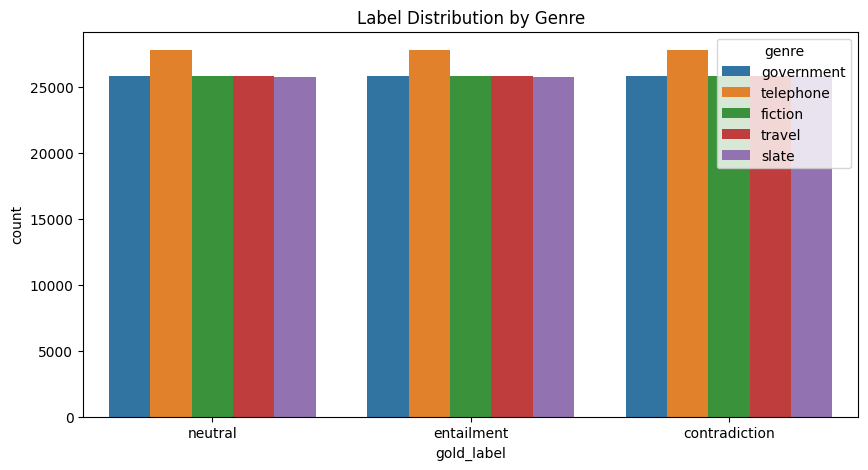

In [28]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='gold_label', hue='genre')
plt.title('Label Distribution by Genre')
plt.show()


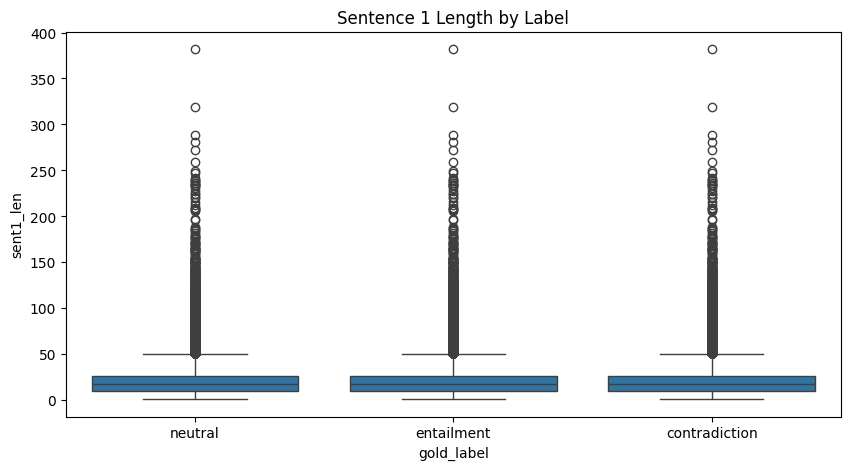

In [29]:
# Viusualisation de la distribution des longueurs de phrases par label
df['sent1_len'] = df['sentence1'].str.split().apply(len)
df['sent2_len'] = df['sentence2'].str.split().apply(len)
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='gold_label', y='sent1_len')
plt.title('Sentence 1 Length by Label')
plt.show()